# Dual-Stream Sign Language Recognition — 5-Sign Dataset
### COMP 5405 — Group 11 | yche0044 · ajaw0192 · jmar0565

**Dataset:** Custom `dataset_5_signs` — 5 ASL words, folder-per-class structure  
**Task:** Isolated word recognition (video → predicted ASL word label)  
**Architecture:** Dual-Stream (RGB + Keypoint) -> DSFF -> TBT -> Classifier

**Resume training:** Set `RESUME = True` in Cell 8 to continue from a saved checkpoint instead of training from scratch.

## Cell 1 — Install Dependencies

In [46]:
# Uncomment this block to download the required dependencies
#!pip install -q opencv-python-headless einops matplotlib tqdm pandas scikit-learn mediapipe
#print('All dependencies installed.')

## Cell 2 — Imports & Config

In [47]:
import json, math, random, warnings, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report

import cv2
import mediapipe as mp

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
from einops import rearrange

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

DATASET_ROOT = Path('./dataset_5_signs')   # <-- change this to your own dataset path


assert DATASET_ROOT.exists(), f'Dataset not found at {DATASET_ROOT}'

CFG = {
    # Dataset
    'dataset_root':  str(DATASET_ROOT),
    'val_split':     0.15,
    'test_split':    0.10,

    # Video preprocessing
    'max_frames':    64,
    'frame_size':    (112, 112),

    # Keypoint cache
    'kp_cache_dir':  './kp_cache_10signs',

    # Stream A — RGB
    'd_model':       512,
    'vit_layers':    2,
    'vit_heads':     4,

    # Stream B — Keypoint
    'stgcn_channels': [32, 64, 128],

    # TBT
    'tbt_layers':    2,
    'tbt_heads':     4,
    'lambda_tbt':    0.3,

    # Classifier
    'dec_hidden':    256,


    'epochs':           15,
    'early_stop_patience': 5,   # early stop if val acc doesn't improve for 5 epochs

    'batch_size':    8,
    'lr':            3e-4,
    'weight_decay':  1e-4,
    'grad_clip':     1.0,
    'warmup_steps':  50,       
    'label_smoothing': 0.1,

    # Output
    'checkpoint_dir': './checkpoints',
    'results_dir':    './results',
}

Path(CFG['kp_cache_dir']).mkdir(parents=True, exist_ok=True)
Path(CFG['checkpoint_dir']).mkdir(parents=True, exist_ok=True)
Path(CFG['results_dir']).mkdir(parents=True, exist_ok=True)
print('Config ready.')


Device : cpu
Config ready.


## Cell 3 — Load Dataset from Folder Structure

Scans `dataset_5_signs/<class_name>/*.mp4` and builds the sample list + label mappings automatically.

Classes found : 5  →  ['bye', 'can', 'help', 'no', 'yes']
Total clips   : 1018
Skipped (tiny/corrupt): 3

Per-class clip counts:
  bye            : 463
  can            : 537
  help           : 5
  no             : 6
  yes            : 7


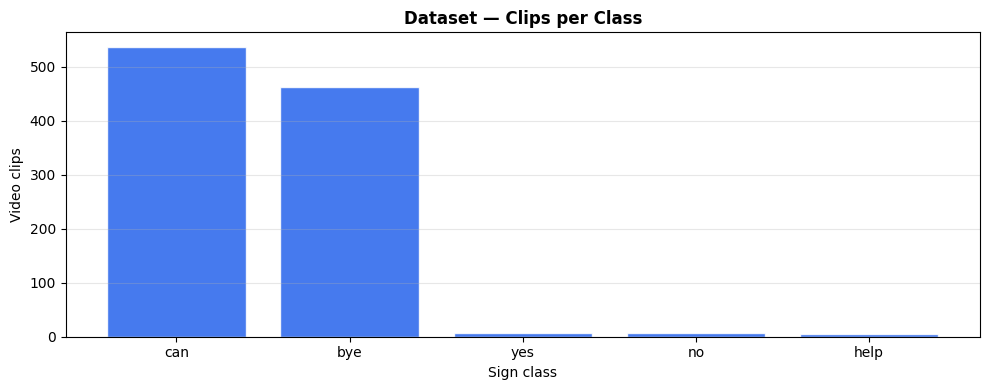

In [48]:
def load_folder_dataset(root: Path):
    class_dirs = sorted([d for d in root.iterdir() if d.is_dir()])
    assert len(class_dirs) > 0, f'No class subdirectories found in {root}'

    class2idx = {d.name: i for i, d in enumerate(class_dirs)}
    idx2class = {v: k for k, v in class2idx.items()}

    samples, skipped = [], []
    for d in class_dirs:
        gloss = d.name
        label = class2idx[gloss]
        for vid in d.glob('*.mp4'):
            if vid.stat().st_size < 1024:
                skipped.append(str(vid))
                continue
            samples.append({'path': str(vid), 'label': label, 'gloss': gloss})

    return samples, class2idx, idx2class, skipped


all_samples, CLASS2IDX, IDX2CLASS, skipped = load_folder_dataset(DATASET_ROOT)
N_CLASSES = len(CLASS2IDX)
CFG['n_classes'] = N_CLASSES

print(f'Classes found : {N_CLASSES}  →  {list(CLASS2IDX.keys())}')
print(f'Total clips   : {len(all_samples)}')
if skipped:
    print(f'Skipped (tiny/corrupt): {len(skipped)}')

counts = Counter(s['gloss'] for s in all_samples)
print('\nPer-class clip counts:')
for gloss, cnt in sorted(counts.items()):
    print(f'  {gloss:15s}: {cnt}')

labels_p = list(counts.keys())
vals_p   = [counts[l] for l in labels_p]
sort_idx = np.argsort(vals_p)[::-1]
labels_p = [labels_p[i] for i in sort_idx]
vals_p   = [vals_p[i]   for i in sort_idx]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(labels_p, vals_p, color='#2563EB', alpha=0.85, edgecolor='white')
ax.set_xlabel('Sign class'); ax.set_ylabel('Video clips')
ax.set_title('Dataset — Clips per Class', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{CFG['results_dir']}/dataset_overview.png", dpi=150)
plt.show()


## Cell 4 — Pre-Extract MediaPipe Keypoints (Run Once, Then Cached)

In [49]:
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
import urllib.request

MODELS = {
    'pose': ('pose_landmarker_full.task',
             'https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/latest/pose_landmarker_full.task'),
    'hand': ('hand_landmarker.task',
             'https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/latest/hand_landmarker.task'),
}

for key, (fname, url) in MODELS.items():
    if not Path(fname).exists():
        print(f'Downloading {fname}...')
        urllib.request.urlretrieve(url, fname)
        print(f'  Done.')
    else:
        print(f'  {fname} already exists.')
print('Models ready.\n')


class KeypointExtractor:
    BODY  = 33
    FACE  = 468
    HAND  = 21
    TOTAL = 33 + 468 + 21 + 21  # 543

    def __init__(self):
        pose_opts = mp_python.BaseOptions(model_asset_path='pose_landmarker_full.task')
        pose_cfg  = mp_vision.PoseLandmarkerOptions(
            base_options=pose_opts,
            running_mode=mp_vision.RunningMode.VIDEO,
            num_poses=1,
            min_pose_detection_confidence=0.5,
            min_pose_presence_confidence=0.5,
            min_tracking_confidence=0.5,
        )
        self.pose_landmarker = mp_vision.PoseLandmarker.create_from_options(pose_cfg)

        hand_opts = mp_python.BaseOptions(model_asset_path='hand_landmarker.task')
        hand_cfg  = mp_vision.HandLandmarkerOptions(
            base_options=hand_opts,
            running_mode=mp_vision.RunningMode.VIDEO,
            num_hands=2,
            min_hand_detection_confidence=0.5,
            min_hand_presence_confidence=0.5,
            min_tracking_confidence=0.5,
        )
        self.hand_landmarker = mp_vision.HandLandmarker.create_from_options(hand_cfg)
        self._timestamp_ms = 0

    def _lm_to_list(self, landmarks, n):
        out = [[0.0, 0.0, 0.0] for _ in range(n)]
        for i, lm in enumerate(landmarks[:n]):
            out[i] = [lm.x, lm.y, lm.z]
        return out

    def extract_frame(self, bgr):
        self._timestamp_ms += 33
        rgb_frame = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        mp_image  = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)

        pose_result = self.pose_landmarker.detect_for_video(mp_image, self._timestamp_ms)
        pose_pts = self._lm_to_list(pose_result.pose_landmarks[0], self.BODY) \
                   if pose_result.pose_landmarks else [[0.0, 0.0, 0.0]] * self.BODY

        face_pts = [[0.0, 0.0, 0.0]] * self.FACE

        hand_result = self.hand_landmarker.detect_for_video(mp_image, self._timestamp_ms)
        left_pts  = [[0.0, 0.0, 0.0]] * self.HAND
        right_pts = [[0.0, 0.0, 0.0]] * self.HAND
        for i, handedness_list in enumerate(hand_result.handedness):
            label = handedness_list[0].category_name
            lms   = self._lm_to_list(hand_result.hand_landmarks[i], self.HAND)
            if label == 'Left':
                left_pts = lms
            else:
                right_pts = lms

        return np.array(pose_pts + face_pts + left_pts + right_pts, dtype=np.float32)

    def extract_video(self, path, max_frames):
        cap = cv2.VideoCapture(str(path))
        if not cap.isOpened():
            print(f'Warning: could not open {path}')
            return np.zeros((max_frames, self.TOTAL, 3), dtype=np.float32), 0

        frames = []
        while cap.isOpened() and len(frames) < max_frames:
            ret, fr = cap.read()
            if not ret:
                break
            frames.append(self.extract_frame(fr))
        cap.release()

        T_real = len(frames)
        if T_real == 0:
            return np.zeros((max_frames, self.TOTAL, 3), dtype=np.float32), 0
        pad = [np.zeros((self.TOTAL, 3), dtype=np.float32)] * (max_frames - T_real)
        return np.stack(frames + pad), T_real

    def close(self):
        self.pose_landmarker.close()
        self.hand_landmarker.close()


def preextract_all_keypoints(samples, cache_dir, max_frames, force=False):
    cache_dir = Path(cache_dir)
    extractor = KeypointExtractor()
    skipped = processed = errors = 0

    for sample in tqdm(samples, desc='Extracting keypoints'):
        vid_path  = Path(sample['path'])
        cache_key = f"{sample['gloss']}_{vid_path.stem}"
        npy_path  = cache_dir / f'{cache_key}.npy'

        if npy_path.exists() and not force:
            skipped += 1
            continue
        try:
            kp, _ = extractor.extract_video(str(vid_path), max_frames)
            np.save(npy_path, kp)
            processed += 1
        except Exception as e:
            print(f'Error processing {vid_path.name}: {e}')
            errors += 1

    extractor.close()
    print(f'Keypoints extracted: {processed} new  |  {skipped} cached  |  {errors} errors')


print(f'Cache directory : {CFG["kp_cache_dir"]}')
print('Running keypoint extraction...\n')
preextract_all_keypoints(all_samples, CFG['kp_cache_dir'], CFG['max_frames'])
print('Keypoint extraction complete.')


I0000 00:00:1778933563.961804 17870708 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M4 Pro
W0000 00:00:1778933564.018129 26902495 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1778933564.027930 26902495 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1778933564.029425 17870708 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M4 Pro
W0000 00:00:1778933564.033620 26902514 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1778933564.037197 26902519 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


  pose_landmarker_full.task already exists.
  hand_landmarker.task already exists.
Models ready.

Cache directory : ./kp_cache_10signs
Running keypoint extraction...



Extracting keypoints: 100%|█████████████| 1018/1018 [00:00<00:00, 135695.72it/s]

Keypoints extracted: 0 new  |  1018 cached  |  0 errors
Keypoint extraction complete.


## Cell 5 — Dataset Class & DataLoaders

In [50]:
RGB_TRANSFORM = T.Compose([
    T.ToPILImage(),
    T.Resize(CFG['frame_size']),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

RGB_TRANSFORM_TRAIN = T.Compose([
    T.ToPILImage(),
    T.Resize(CFG['frame_size']),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class SignDataset(Dataset):
    def __init__(self, samples, kp_cache_dir, max_frames, augment=False):
        self.samples      = samples
        self.kp_cache_dir = Path(kp_cache_dir)
        self.max_frames   = max_frames
        self.transform    = RGB_TRANSFORM_TRAIN if augment else RGB_TRANSFORM

    def __len__(self):
        return len(self.samples)

    def _load_rgb(self, path):
        cap    = cv2.VideoCapture(str(path))
        frames = []
        while cap.isOpened() and len(frames) < self.max_frames:
            ret, fr = cap.read()
            if not ret:
                break
            frames.append(self.transform(cv2.cvtColor(fr, cv2.COLOR_BGR2RGB)))
        cap.release()
        T_real = len(frames)
        if T_real == 0:
            return torch.zeros(self.max_frames, 3, *CFG['frame_size']), 0
        pad = [torch.zeros(3, *CFG['frame_size'])] * (self.max_frames - T_real)
        return torch.stack(frames + pad), T_real

    def _load_kp(self, gloss, vid_stem):
        npy = self.kp_cache_dir / f'{gloss}_{vid_stem}.npy'
        if npy.exists():
            return torch.from_numpy(np.load(npy))
        return torch.zeros(self.max_frames, 543, 3)

    def __getitem__(self, idx):
        s        = self.samples[idx]
        vid_path = Path(s['path'])
        rgb, T_real = self._load_rgb(s['path'])
        kp          = self._load_kp(s['gloss'], vid_path.stem)
        mask          = torch.zeros(self.max_frames)
        mask[:T_real] = 1.0
        return {
            'rgb':   rgb,
            'kp':    kp,
            'label': torch.tensor(s['label'], dtype=torch.long),
            'gloss': s['gloss'],
            'mask':  mask,
        }


random.shuffle(all_samples)
n       = len(all_samples)
n_test  = max(1, int(n * CFG['test_split']))
n_val   = max(1, int(n * CFG['val_split']))
n_train = n - n_val - n_test

train_samples = all_samples[:n_train]
val_samples   = all_samples[n_train : n_train + n_val]
test_samples  = all_samples[n_train + n_val:]

print(f'Split  ->  Train: {len(train_samples)} | Val: {len(val_samples)} | Test: {len(test_samples)}')

train_ds = SignDataset(train_samples, CFG['kp_cache_dir'], CFG['max_frames'], augment=True)
val_ds   = SignDataset(val_samples,   CFG['kp_cache_dir'], CFG['max_frames'], augment=False)
test_ds  = SignDataset(test_samples,  CFG['kp_cache_dir'], CFG['max_frames'], augment=False)

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'], shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=CFG['batch_size'], shuffle=False, num_workers=0, pin_memory=False)

print('DataLoaders ready.')


Split  ->  Train: 765 | Val: 152 | Test: 101
DataLoaders ready.


## Cell 6 — Visualise Sample Clips

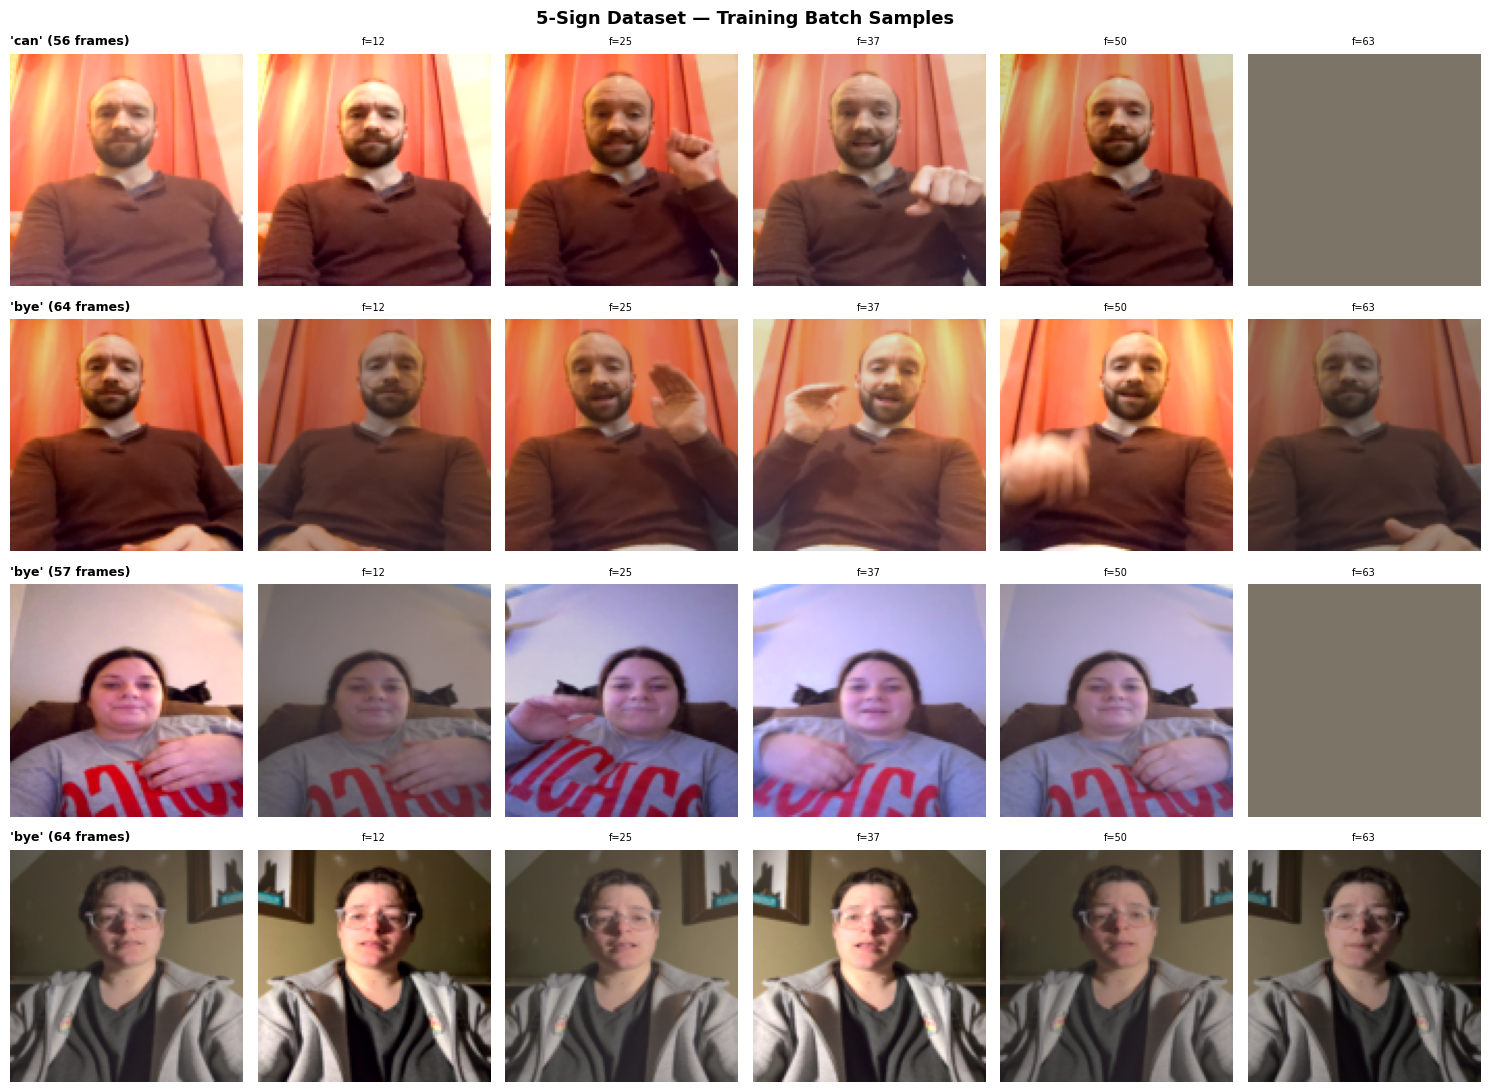

Keypoint shape : torch.Size([64, 543, 3])  (T=64, N=543, coords=3)
Valid frames   : 56


In [51]:
def denorm(t):
    m = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    s = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (t * s + m).clamp(0, 1)

batch = next(iter(train_loader))
B     = min(4, batch['rgb'].size(0))
N_FRAMES_SHOW = 6
idxs  = np.linspace(0, CFG['max_frames'] - 1, N_FRAMES_SHOW, dtype=int)

fig, axes = plt.subplots(B, N_FRAMES_SHOW, figsize=(15, 2.8 * B))
if B == 1: axes = axes[np.newaxis, :]

for row in range(B):
    gloss  = batch['gloss'][row]
    T_real = int(batch['mask'][row].sum().item())
    for col, fi in enumerate(idxs):
        frame = denorm(batch['rgb'][row, fi]).permute(1, 2, 0).numpy()
        axes[row, col].imshow(frame)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(f"'{gloss}' ({T_real} frames)", fontsize=9, loc='left', fontweight='bold')
        else:
            axes[row, col].set_title(f'f={fi}', fontsize=7)

plt.suptitle('5-Sign Dataset — Training Batch Samples', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{CFG['results_dir']}/sample_clips.png", dpi=150)
plt.show()

kp = batch['kp'][0]
T_real = int(batch['mask'][0].sum())
print(f'Keypoint shape : {kp.shape}  (T={CFG["max_frames"]}, N=543, coords=3)')
print(f'Valid frames   : {T_real}')


## Cell 7 — Model Architecture

In [52]:
class RGBStream(nn.Module):
    def __init__(self, d_model, vit_layers, vit_heads, max_frames):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        for name, p in resnet.named_parameters():
            if not any(x in name for x in ['layer3', 'layer4', 'fc']):
                p.requires_grad = False
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        self.proj     = nn.Linear(2048, d_model)
        self.pos_emb  = nn.Parameter(torch.randn(1, max_frames, d_model) * 0.02)
        enc = nn.TransformerEncoderLayer(d_model, vit_heads, d_model * 2, 0.1, batch_first=True, norm_first=True)
        self.vit  = nn.TransformerEncoder(enc, vit_layers)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, rgb, mask=None):
        B, T = rgb.shape[:2]
        x = rearrange(rgb, 'b t c h w -> (b t) c h w')
        x = self.backbone(x).flatten(1)
        x = self.proj(x)
        x = rearrange(x, '(b t) d -> b t d', b=B, t=T)
        x = x + self.pos_emb[:, :T]
        kpm = (mask == 0) if mask is not None else None
        return self.norm(self.vit(x, src_key_padding_mask=kpm))


class STGCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, t_kernel=5):
        super().__init__()
        self.gcn  = nn.Conv1d(in_ch, out_ch, 1)
        self.tcn  = nn.Sequential(
            nn.BatchNorm1d(out_ch), nn.ReLU(),
            nn.Conv1d(out_ch, out_ch, t_kernel, padding=t_kernel // 2),
            nn.BatchNorm1d(out_ch),
        )
        self.skip = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.tcn(self.gcn(x)) + self.skip(x))


class KeypointStream(nn.Module):
    def __init__(self, d_model, channels):
        super().__init__()
        layers, in_ch = [], 3
        for out_ch in channels:
            layers.append(STGCNBlock(in_ch, out_ch))
            in_ch = out_ch
        self.stgcn  = nn.Sequential(*layers)
        self.bilstm = nn.LSTM(channels[-1], d_model // 2, num_layers=2,
                              batch_first=True, bidirectional=True, dropout=0.1)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, kp):
        B, T, N, C = kp.shape
        x = rearrange(kp, 'b t n c -> (b n) c t')
        x = self.stgcn(x)
        x = rearrange(x, '(b n) c t -> b n c t', b=B, n=N).mean(1)
        x = rearrange(x, 'b c t -> b t c')
        out, _ = self.bilstm(x)
        return self.norm(out)


class DSFF(nn.Module):
    def __init__(self, d_model, nhead, out_dim):
        super().__init__()
        self.ca_A  = nn.MultiheadAttention(d_model, nhead, 0.1, batch_first=True)
        self.ca_B  = nn.MultiheadAttention(d_model, nhead, 0.1, batch_first=True)
        self.proj  = nn.Linear(2 * d_model, out_dim)
        self.normA = nn.LayerNorm(d_model)
        self.normB = nn.LayerNorm(d_model)
        self.norm  = nn.LayerNorm(out_dim)

    def forward(self, A, B, key_mask=None):
        At, _ = self.ca_A(A, B, B, key_padding_mask=key_mask)
        Bt, _ = self.ca_B(B, A, A, key_padding_mask=key_mask)
        At = self.normA(A + At)
        Bt = self.normB(B + Bt)
        return self.norm(self.proj(torch.cat([At, Bt], dim=-1)))


class TBT(nn.Module):
    def __init__(self, d_model, n_layers, nhead):
        super().__init__()
        enc = nn.TransformerEncoderLayer(d_model, nhead, d_model, 0.1, batch_first=True, norm_first=True)
        self.enc  = nn.TransformerEncoder(enc, n_layers)
        self.head = nn.Sequential(nn.Linear(d_model, 64), nn.ReLU(), nn.Linear(64, 1), nn.Sigmoid())

    def forward(self, x, mask=None):
        kpm = (mask == 0) if mask is not None else None
        z   = self.enc(x, src_key_padding_mask=kpm)
        p_t = self.head(z).squeeze(-1)
        return p_t, z

    @staticmethod
    def bce_loss(p_t, y_t, mask):
        loss = F.binary_cross_entropy(p_t, y_t.float(), reduction='none')
        return (loss * mask).sum() / mask.sum().clamp(min=1)


class ClassHead(nn.Module):
    def __init__(self, d_model, n_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(d_model, d_model), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(d_model, n_classes)
        )

    def forward(self, z, mask=None):
        if mask is not None:
            me = mask.unsqueeze(-1)
            pooled = (z * me).sum(1) / me.sum(1).clamp(min=1)
        else:
            pooled = z.mean(1)
        return self.mlp(pooled)


class DualStreamSLR(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        d  = cfg['d_model']
        dd = cfg['dec_hidden']
        self.stream_a = RGBStream(d, cfg['vit_layers'], cfg['vit_heads'], cfg['max_frames'])
        self.stream_b = KeypointStream(d, cfg['stgcn_channels'])
        self.dsff     = DSFF(d, 4, dd)
        self.tbt      = TBT(dd, cfg['tbt_layers'], cfg['tbt_heads'])
        self.head     = ClassHead(dd, cfg['n_classes'])
        self.lambda_b = cfg['lambda_tbt']

    def forward(self, rgb, kp, mask=None):
        Z_A      = self.stream_a(rgb, mask)
        Z_B      = self.stream_b(kp)
        km       = (mask == 0) if mask is not None else None
        Z_f      = self.dsff(Z_A, Z_B, km)
        p_t, Z_e = self.tbt(Z_f, mask)
        logits   = self.head(Z_e, mask)
        return logits, p_t

    def loss(self, logits, labels, p_t, bnd_labels, mask, label_smoothing=0.1):
        cls = F.cross_entropy(logits, labels, label_smoothing=label_smoothing)
        bnd = TBT.bce_loss(p_t, bnd_labels, mask)
        return cls + self.lambda_b * bnd, cls.item(), bnd.item()


model = DualStreamSLR(CFG).to(DEVICE)

def count(m):           return sum(p.numel() for p in m.parameters())
def count_trainable(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)

print('\nArchitecture:')
for name, sub in [('Stream A (ResNet+ViT)', model.stream_a),
                   ('Stream B (STGCN+BiLSTM)', model.stream_b),
                   ('DSFF', model.dsff), ('TBT', model.tbt), ('ClassHead', model.head)]:
    print(f'  {name:24s}  {count(sub):>10,} params')
print(f'  {"TOTAL":24s}  {count(model):>10,} params')
print(f'  {"TRAINABLE":24s}  {count_trainable(model):>10,} params')
print(f'\nClasses: {N_CLASSES}')
print('Model ready.')



Architecture:
  Stream A (ResNet+ViT)     28,796,480 params
  Stream B (STGCN+BiLSTM)    2,498,272 params
  DSFF                       2,366,208 params
  TBT                          808,065 params
  ClassHead                     67,077 params
  TOTAL                     34,536,102 params
  TRAINABLE                 33,091,174 params

Classes: 5
Model ready.


## Cell 8 — Training

**Two modes — set `RESUME` below:**

- `RESUME = False` — trains from scratch, saves a checkpoint every epoch and the best checkpoint separately
- `RESUME = True` — loads the last saved checkpoint and continues training from where it left off

Training also stops automatically via early stopping if val accuracy plateaus.

In [18]:
RESUME = True   # <-- Set to true if wish to continue from last saved checkpoint


BEST_CKPT  = Path(CFG['checkpoint_dir']) / 'best_10signs.pt'
LAST_CKPT  = Path(CFG['checkpoint_dir']) / 'last_10signs.pt'


def make_boundary_labels(mask, n_bounds=5):
    B, T   = mask.shape
    labels = torch.zeros(B, T, device=mask.device)
    step   = max(1, T // (n_bounds + 1))
    for i in range(1, n_bounds + 1):
        labels[:, min(i * step, T - 1)] = 1.0
    return labels * mask


def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    tot_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        rgb    = batch['rgb'].to(device)
        kp     = batch['kp'].to(device)
        labels = batch['label'].to(device)
        mask   = batch['mask'].to(device)
        bnd_y  = make_boundary_labels(mask)

        optimizer.zero_grad()
        logits, p_t = model(rgb, kp, mask)
        loss, _, _  = model.loss(logits, labels, p_t, bnd_y, mask, CFG['label_smoothing'])
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
        optimizer.step()
        if scheduler is not None:
            scheduler.step()

        tot_loss += loss.item() * labels.size(0)
        correct  += (logits.argmax(1) == labels).sum().item()
        total    += labels.size(0)
    return tot_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, device):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    for batch in loader:
        rgb    = batch['rgb'].to(device)
        kp     = batch['kp'].to(device)
        labels = batch['label'].to(device)
        mask   = batch['mask'].to(device)
        logits, _ = model(rgb, kp, mask)
        preds  = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    return correct / total, all_preds, all_labels


def compute_val_loss(model, loader, device):
    model.eval()
    total_loss, total_n = 0.0, 0
    with torch.no_grad():
        for batch in loader:
            rgb    = batch['rgb'].to(device)
            kp     = batch['kp'].to(device)
            labels = batch['label'].to(device)
            mask   = batch['mask'].to(device)
            bnd_y  = make_boundary_labels(mask)
            logits, p_t = model(rgb, kp, mask)
            loss, _, _ = model.loss(logits, labels, p_t, bnd_y, mask, CFG['label_smoothing'])
            total_loss += loss.item() * labels.size(0)
            total_n    += labels.size(0)
    return total_loss / total_n


def save_checkpoint(path, epoch, model, optimizer, scheduler, history, best_acc, patience_counter):
    torch.save({
        'epoch':           epoch,
        'state_dict':      model.state_dict(),
        'optimizer':       optimizer.state_dict(),
        'scheduler':       scheduler.state_dict(),
        'history':         history,
        'best_acc':        best_acc,
        'patience_counter': patience_counter,
        'cfg':             CFG,
        'class2idx':       CLASS2IDX,
        'idx2class':       IDX2CLASS,
    }, path)


# Build optimizer & scheduler 
optimizer   = torch.optim.AdamW(model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
total_steps = CFG['epochs'] * len(train_loader)

def lr_lambda(step):
    w = CFG['warmup_steps']
    if step < w:
        return step / max(1, w)
    p = (step - w) / max(1, total_steps - w)
    return max(0.0, 0.5 * (1 + math.cos(math.pi * p)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# Resume or start fresh 
start_epoch      = 1
best_acc         = 0.0
patience_counter = 0
history          = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}

if RESUME and LAST_CKPT.exists():
    print(f'Resuming from {LAST_CKPT} ...')
    ckpt = torch.load(LAST_CKPT, map_location=DEVICE)
    model.load_state_dict(ckpt['state_dict'])
    optimizer.load_state_dict(ckpt['optimizer'])
    scheduler.load_state_dict(ckpt['scheduler'])
    history          = ckpt['history']
    best_acc         = ckpt['best_acc']
    patience_counter = ckpt['patience_counter']
    start_epoch      = ckpt['epoch'] + 1
    print(f'  Resumed at epoch {start_epoch}  |  best val acc so far: {best_acc*100:.1f}%')
elif RESUME:
    print('No saved checkpoint found — starting from scratch.')

print(f'\nTraining epochs {start_epoch} → {CFG["epochs"]}  (early-stop patience={CFG["early_stop_patience"]})\n')

# Training loop 
for epoch in range(start_epoch, CFG['epochs'] + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, scheduler, DEVICE)
    val_acc, _, _   = eval_epoch(model, val_loader, DEVICE)
    val_loss        = compute_val_loss(model, val_loader, DEVICE)
    cur_lr          = optimizer.param_groups[0]['lr']

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc * 100)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc * 100)
    history['lr'].append(cur_lr)

    # Save last checkpoint every epoch (enables resume) 
    save_checkpoint(LAST_CKPT, epoch, model, optimizer, scheduler,
                    history, best_acc, patience_counter)

    # Save best checkpoint when val accuracy improves 
    flag = ''
    if val_acc > best_acc:
        best_acc         = val_acc
        patience_counter = 0
        save_checkpoint(BEST_CKPT, epoch, model, optimizer, scheduler,
                        history, best_acc, patience_counter)
        flag = '  ← best  [saved]'
    else:
        patience_counter += 1

    print(f'Ep {epoch:02d}/{CFG["epochs"]} | '
          f'Loss {tr_loss:.4f} | '
          f'Train {tr_acc*100:.1f}% | '
          f'Val {val_acc*100:.1f}% | '
          f'LR {cur_lr:.2e} | '
          f'Patience {patience_counter}/{CFG["early_stop_patience"]}{flag}')

    #  Early stopping 
    if patience_counter >= CFG['early_stop_patience']:
        print(f'\nEarly stopping triggered — val accuracy has not improved for {patience_counter} epochs.')
        break

print(f'\nDone. Best val accuracy: {best_acc*100:.1f}%')
print(f'Checkpoints saved to: {CFG["checkpoint_dir"]}/')
print(f'  best_10signs.pt  — best val accuracy ever')
print(f'  last_10signs.pt  — last completed epoch (use for resuming)')


Resuming from checkpoints/last_10signs.pt ...
  Resumed at epoch 11  |  best val acc so far: 90.8%

Training epochs 11 → 15  (early-stop patience=5)

Ep 11/15 | Loss 0.6842 | Train 92.0% | Val 90.8% | LR 5.30e-05 | Patience 2/5
Ep 12/15 | Loss 0.6453 | Train 93.3% | Val 90.8% | LR 3.07e-05 | Patience 3/5
Ep 13/15 | Loss 0.6446 | Train 93.5% | Val 90.8% | LR 1.39e-05 | Patience 4/5
Ep 14/15 | Loss 0.6481 | Train 92.9% | Val 90.8% | LR 3.52e-06 | Patience 5/5

Early stopping triggered — val accuracy has not improved for 5 epochs.

Done. Best val accuracy: 90.8%
Checkpoints saved to: ./checkpoints/
  best_10signs.pt  — best val accuracy ever
  last_10signs.pt  — last completed epoch (use for resuming)


## Cell 9 — Training Curves

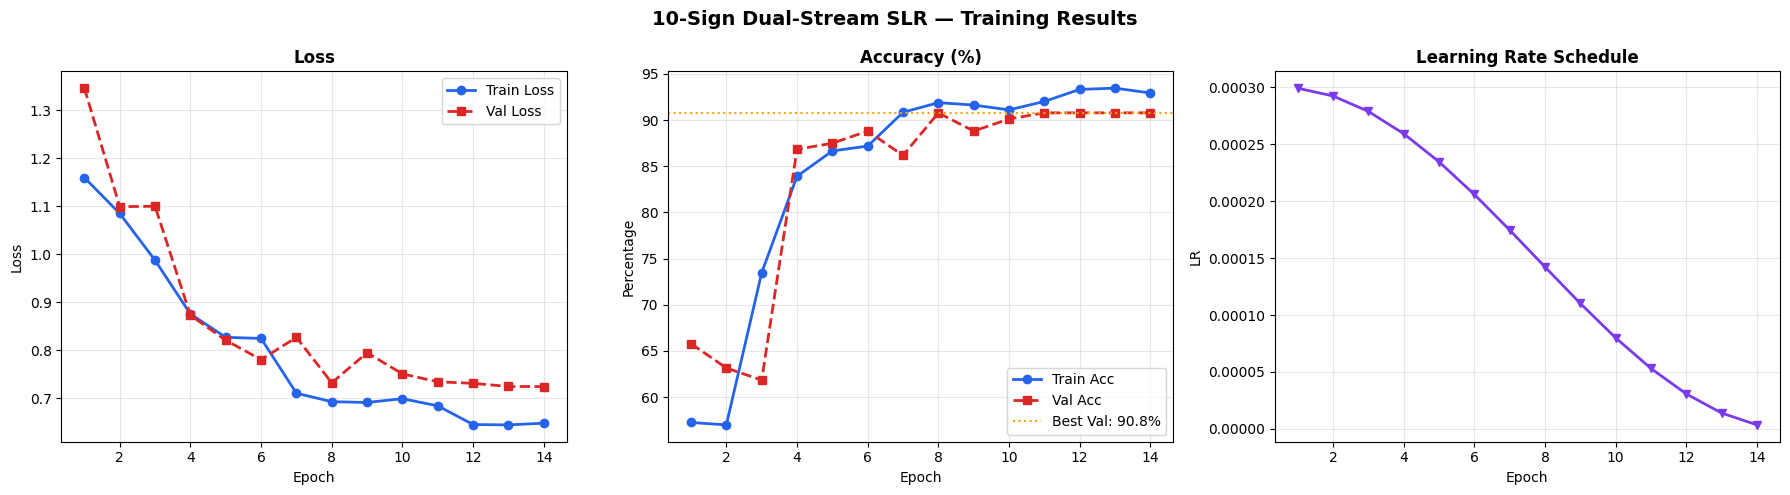

Best Validation Accuracy: 90.79%


In [53]:
epochs_range = range(1, len(history['train_loss']) + 1)
best_val_acc = max(history['val_acc'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_range, history['train_loss'], color='#2563EB', marker='o', linewidth=2, label='Train Loss')
axes[0].plot(epochs_range, history['val_loss'],   color='#DC2626', marker='s', linewidth=2, linestyle='--', label='Val Loss')
axes[0].set_title('Loss', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history['train_acc'], color='#2563EB', marker='o', linewidth=2, label='Train Acc')
axes[1].plot(epochs_range, history['val_acc'],   color='#DC2626', marker='s', linewidth=2, linestyle='--', label='Val Acc')
axes[1].axhline(best_val_acc, color='orange', linestyle=':', label=f'Best Val: {best_val_acc:.1f}%')
axes[1].set_title('Accuracy (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Percentage')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_range, history['lr'], color='#7C3AED', linewidth=2, marker='v')
axes[2].set_title('Learning Rate Schedule', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR')
axes[2].grid(True, alpha=0.3)

plt.suptitle('10-Sign Dual-Stream SLR — Training Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{CFG['results_dir']}/training_curves.png", bbox_inches='tight', dpi=150)
plt.show()
print(f'Best Validation Accuracy: {best_val_acc:.2f}%')


## Cell 10 — Test Set Evaluation & Confusion Matrix

Loaded best checkpoint from epoch 8  (val acc: 90.8%)

TEST SET RESULTS
Test Accuracy: 87.13%

              precision    recall  f1-score   support

         bye       0.95      0.84      0.89        50
         can       0.81      0.96      0.88        48
        help       0.00      0.00      0.00         2
          no       0.00      0.00      0.00         1
         yes       0.00      0.00      0.00         0

    accuracy                           0.87       101
   macro avg       0.35      0.36      0.35       101
weighted avg       0.86      0.87      0.86       101



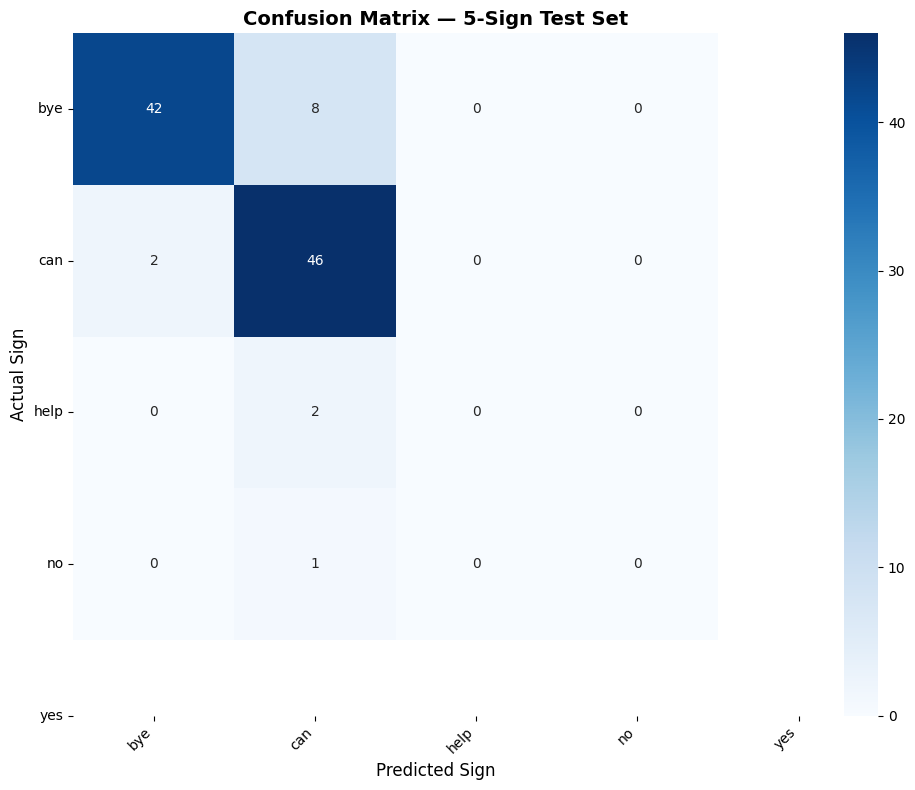

In [54]:
import seaborn as sns

# Loads the BEST checkpoint (highest val accuracy), not the last one
ckpt = torch.load(BEST_CKPT, map_location=DEVICE)
model.load_state_dict(ckpt['state_dict'])
print(f"Loaded best checkpoint from epoch {ckpt['epoch']}  (val acc: {ckpt['best_acc']*100:.1f}%)")

test_acc, all_preds, all_labels = eval_epoch(model, test_loader, DEVICE)
class_names = [IDX2CLASS[i] for i in range(N_CLASSES)]

print('\n' + '='*40)
print('TEST SET RESULTS')
print('='*40)
print(f'Test Accuracy: {test_acc*100:.2f}%\n')
print(classification_report(all_labels, all_preds,
                             labels=list(range(N_CLASSES)),
                             target_names=class_names,
                             zero_division=0))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title('Confusion Matrix — 5-Sign Test Set', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Sign', fontsize=12)
ax.set_ylabel('Actual Sign', fontsize=12)
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{CFG['results_dir']}/test_confusion_matrix.png", bbox_inches='tight', dpi=150)
plt.show()


## Cell 11 — Extended Evaluation: Per-Class Metrics, Top-K & Confidence Analysis

Comprehensive evaluation of the best model on the **test set**:
- Per-class Precision / Recall / F1 bar charts  
- Top-1 accuracy  
- Confidence score distribution  
- Prediction confidence heatmap by class

In [55]:
import seaborn as sns
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_recall_fscore_support)

# Full test-set inference with probabilities 
model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for batch in test_loader:
        rgb    = batch['rgb'].to(DEVICE)
        kp     = batch['kp'].to(DEVICE)
        labels = batch['label'].to(DEVICE)
        mask   = batch['mask'].to(DEVICE)
        logits, _ = model(rgb, kp, mask)
        probs = F.softmax(logits, dim=-1)
        preds = probs.argmax(1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
        all_probs.extend(probs.cpu().tolist())

all_probs  = np.array(all_probs)  
class_names = [IDX2CLASS[i] for i in range(N_CLASSES)]
N_test = len(all_labels)


In [56]:
# Top-1 accuracy
top1 = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"  Samples evaluated : {N_test}")
print(f"  Top-1 Accuracy    : {top1*100:.2f}%")
print()

  Samples evaluated : 101
  Top-1 Accuracy    : 87.13%



              precision    recall  f1-score   support

         bye       0.95      0.84      0.89        50
         can       0.81      0.96      0.88        48
        help       0.00      0.00      0.00         2
          no       0.00      0.00      0.00         1
         yes       0.00      0.00      0.00         0

    accuracy                           0.87       101
   macro avg       0.35      0.36      0.35       101
weighted avg       0.86      0.87      0.86       101



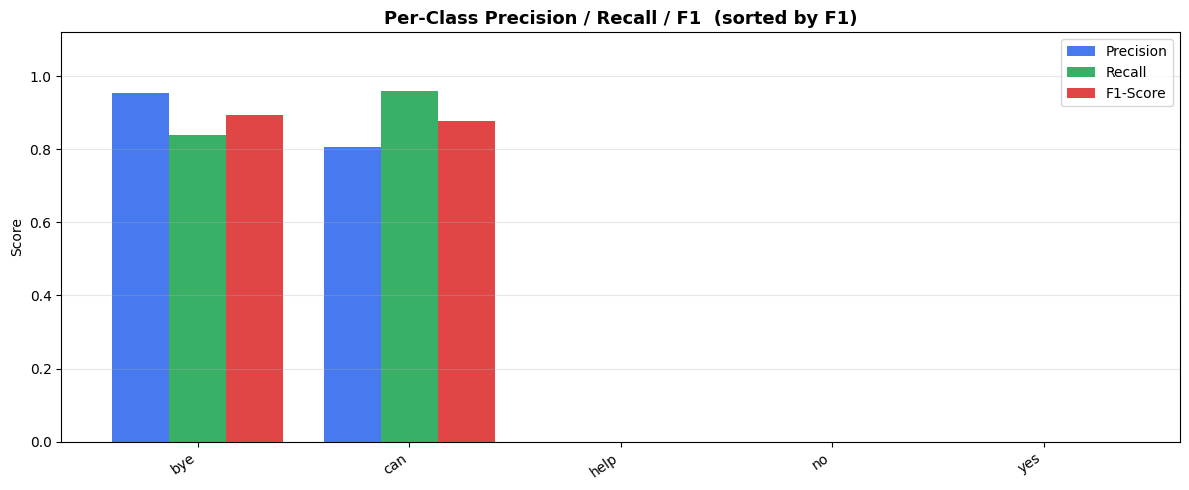

In [57]:
# Per-class report 
print(classification_report(all_labels, all_preds,
                             labels=list(range(N_CLASSES)),
                             target_names=class_names,
                             zero_division=0))

# Per-class Precision / Recall / F1 bar chart 
prec, rec, f1, support = precision_recall_fscore_support(
    all_labels, all_preds, labels=list(range(N_CLASSES)), zero_division=0)

df_metrics = pd.DataFrame({
    'Class'    : class_names,
    'Precision': prec,
    'Recall'   : rec,
    'F1-Score' : f1,
    'Support'  : support,
})
df_metrics = df_metrics.sort_values('F1-Score', ascending=False).reset_index(drop=True)

x  = np.arange(N_CLASSES)
w  = 0.27
fig, ax = plt.subplots(figsize=(max(12, N_CLASSES * 1.2), 5))
ax.bar(x - w,  df_metrics['Precision'], w, label='Precision', color='#2563EB', alpha=0.85)
ax.bar(x,      df_metrics['Recall'],    w, label='Recall',    color='#16A34A', alpha=0.85)
ax.bar(x + w,  df_metrics['F1-Score'], w, label='F1-Score',  color='#DC2626', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(df_metrics['Class'], rotation=35, ha='right')
ax.set_ylim(0, 1.12); ax.set_ylabel('Score'); ax.set_title(
    'Per-Class Precision / Recall / F1  (sorted by F1)', fontweight='bold', fontsize=13)
ax.legend(loc='upper right'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{CFG['results_dir']}/per_class_metrics.png", dpi=150, bbox_inches='tight')
plt.show()

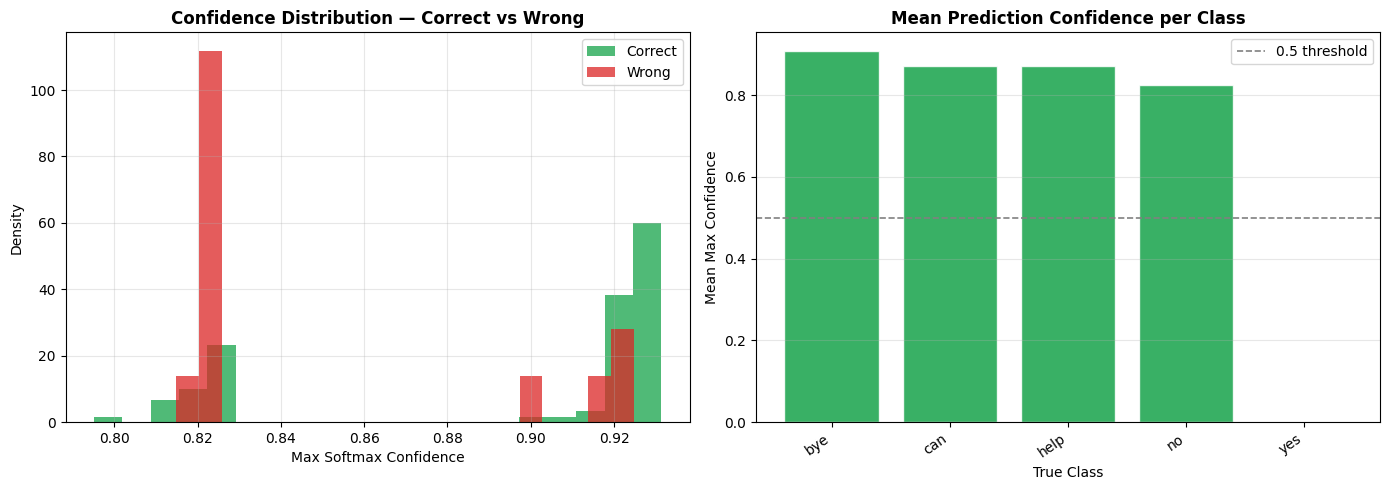

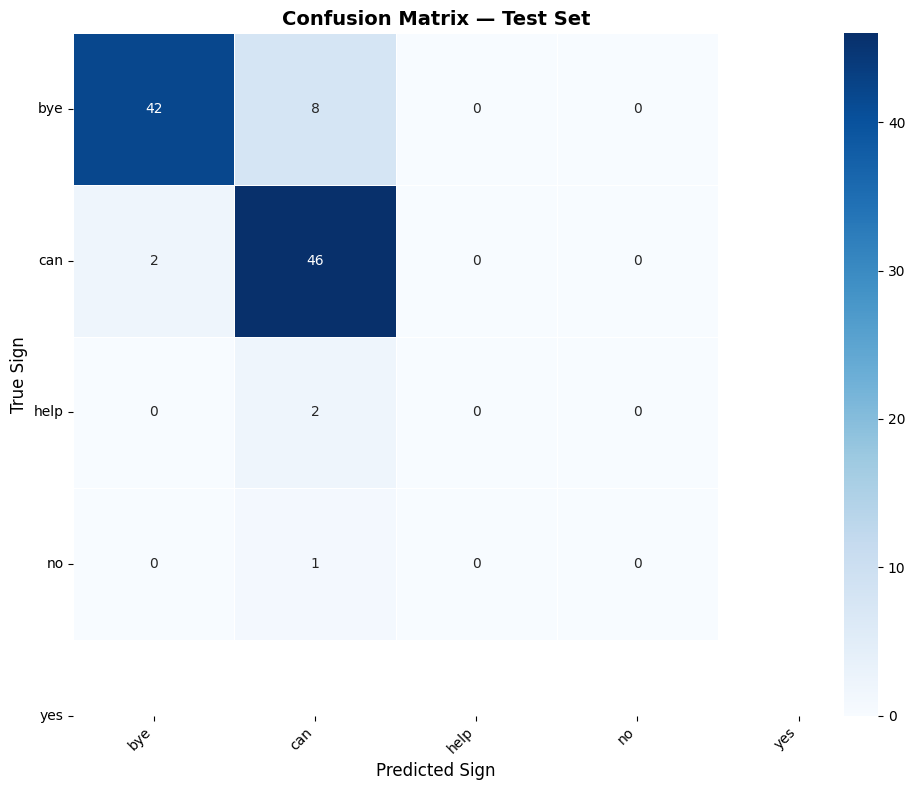


All evaluation plots saved to: ./results/


In [58]:
# Confidence distribution 
top_probs   = all_probs[np.arange(N_test), all_preds]
correct_mask = np.array(all_preds) == np.array(all_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(top_probs[correct_mask],  bins=20, alpha=0.75, color='#16A34A', label='Correct', density=True)
axes[0].hist(top_probs[~correct_mask], bins=20, alpha=0.75, color='#DC2626', label='Wrong',   density=True)
axes[0].set_xlabel('Max Softmax Confidence'); axes[0].set_ylabel('Density')
axes[0].set_title('Confidence Distribution — Correct vs Wrong', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Mean confidence per true class
mean_conf_per_class = [
    top_probs[np.array(all_labels) == i].mean() if (np.array(all_labels) == i).any() else 0
    for i in range(N_CLASSES)
]
colors = ['#16A34A' if c >= 0.5 else '#DC2626' for c in mean_conf_per_class]
axes[1].bar(class_names, mean_conf_per_class, color=colors, alpha=0.85, edgecolor='white')
axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=1.2, label='0.5 threshold')
axes[1].set_xlabel('True Class'); axes[1].set_ylabel('Mean Max Confidence')
axes[1].set_title('Mean Prediction Confidence per Class', fontweight='bold')
plt.setp(axes[1].get_xticklabels(), rotation=35, ha='right')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{CFG['results_dir']}/confidence_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

# Confusion Matrix 
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(max(10, N_CLASSES), max(8, N_CLASSES)))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title('Confusion Matrix — Test Set', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Sign', fontsize=12); ax.set_ylabel('True Sign', fontsize=12)
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{CFG['results_dir']}/confusion_matrix_extended.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAll evaluation plots saved to: {CFG['results_dir']}/")

## Cell 13 — Model Evaluation Summary

In [59]:
print("\n" + "╔" + "═"*53 + "╗")
print("║  DUAL-STREAM SLR — FINAL EVALUATION SUMMARY " + " " * 8 + "║")
print("╠" + "═"*53 + "╣")
print(f"║  Classes             : {N_CLASSES:<28} ║")
print(f"║  Test samples        : {N_test:<28} ║")
print(f"║  Best Val Accuracy   : {ckpt['best_acc']*100:<27.2f}% ║")
print(f"║  Test Top-1 Accuracy : {top1*100:<27.2f}% ║")
print(f"║  Macro F1 (test)     : {np.mean(f1)*100:<27.2f}% ║")
print(f"║  Best checkpoint ep  : {ckpt['epoch']:<28} ║")
print("╚" + "═"*53 + "╝")
print()
print("Saved artefacts:")
for fname in ['per_class_metrics.png', 'confidence_distribution.png',
              'confusion_matrix_extended.png', 'evaluation_summary.csv']:
    print(f"  {CFG['results_dir']}/{fname}")


╔═════════════════════════════════════════════════════╗
║  DUAL-STREAM SLR — FINAL EVALUATION SUMMARY         ║
╠═════════════════════════════════════════════════════╣
║  Classes             : 5                            ║
║  Test samples        : 101                          ║
║  Best Val Accuracy   : 90.79                      % ║
║  Test Top-1 Accuracy : 87.13                      % ║
║  Macro F1 (test)     : 35.40                      % ║
║  Best checkpoint ep  : 8                            ║
╚═════════════════════════════════════════════════════╝

Saved artefacts:
  ./results/per_class_metrics.png
  ./results/confidence_distribution.png
  ./results/confusion_matrix_extended.png
  ./results/evaluation_summary.csv
